# Lazy operator algebra — Sum, Scaled, Product

Notebook 1.1 toured the *leaf* operators: `Diagonal`, `Kronecker`, `BlockDiag`, `LowRankUpdate`. Real covariances are not leaves — they are *expressions*. A noisy GP kernel is $\sigma^2 K + \tau^2 I$. A posterior covariance is $K - K_{*X} K_{XX}^{-1} K_{X*}$. A whitened cross-term is $L^{-1} K L^{-\top}$. Each one is a *combination* of leaves under sum, scalar multiply, and matrix product.

The temptation is to just call `.as_matrix()` on the leaves and add them together. That works, and it throws away every dollar of structure you bought in 1.1: the moment you materialize $\sigma^2 K_{\mathrm{kron}}$, its $n^2 + m^2$ parameters explode into $N^2$ entries, and the next call costs $O(N^3)$ instead of $O(N^{3/2})$.

`gaussx` provides three *lazy* combinators — `SumOperator`, `ScaledOperator`, `ProductOperator` — that defer materialization. They store pointers to the operands and a recipe for matvec; they never form the combined matrix unless someone explicitly asks for it. The leaves keep their structural cost; the tree composes.

What you will see by the end:

- The matvec rules for sum / scaled / product, and why they preserve leaf cost.
- How structural tags propagate: when does a sum stay symmetric? when does a scaled operator stay PSD? (Spoiler: less often than you would expect — `gaussx` is conservative on purpose.)
- A worked composition: $\sigma^2 (K_x \otimes K_y) + \tau^2 I$ assembled lazily on a $32\times 32$ grid.
- The "common idioms" cheatsheet — six expressions every GP user writes, paired with the lazy operator that keeps them cheap.
- The sharp edges: $AB$ is *not* generally symmetric or PSD even when both factors are.

By the end you should write covariance arithmetic by *operator algebra*, not by `jnp.zeros((N, N))` followed by accumulation.

## 0. Where these structures show up in geoscience

Lazy algebra is what lets you write down realistic geophysical covariances without paying $O(N^2)$ to materialize them:

- **Signal + noise**: $\sigma^2 K_{\mathrm{rbf}} + \tau^2 I$ — every regression on satellite retrievals, gridded reanalyses, or station data. The kernel captures spatial correlation; the diagonal captures retrieval / instrument noise. Lazy keeps the kernel structured.
- **Additive kernel decomposition**: $K_{\mathrm{trend}} + K_{\mathrm{seasonal}} + K_{\mathrm{residual}}$ — the classic Mauna Loa CO$_2$ decomposition (Rasmussen & Williams 2006), and any climate-time-series model that separates secular trend, annual cycle, and short-term variability.
- **Heteroscedastic noise**: $K_{XX} + \mathrm{diag}(\sigma_i^2)$ — sparse field campaigns where each observation site has its own precision (Argo float vs ship CTD vs satellite). `Sum(K, DiagonalLinearOperator)` keeps both sides cheap.
- **Spacetime separable + iid noise**: $\sigma^2 (K_{\mathrm{space}} \otimes K_{\mathrm{time}}) + \tau^2 I$ — any gridded reanalysis, ocean colour series, ENSO prediction. Lazy keeps the Kronecker factor unmaterialized; we'll see in 1.3 that the eigendecomposition of this composite is also closed-form.
- **Scaled kernel for output magnitude**: $\sigma_f^2 k(\cdot,\cdot)$ where $\sigma_f^2$ is the signal variance — this is a one-cell example of `ScaledOperator` and shows up in *every* GP regression model.
- **Cross-covariance for prediction**: $K_{*X} K_{XX}^{-1}$ — the predictive-mean machinery for any geophysical interpolation. The inverse stays implicit (Cholesky factor); the cross-product is lazy `Product`.

The lesson: writing covariances by *operator algebra* on top of structured leaves is what makes regional climate / ocean / atmosphere models tractable on commodity GPUs.

In [1]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore", message=r".*IProgress.*")

import einx
import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import numpy as np
from gaussx import (
    Kronecker,
    ProductOperator,
    ScaledOperator,
    SumOperator,
    logdet,
    solve,
)

jax.config.update("jax_enable_x64", True)
KEY = jax.random.PRNGKey(0)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.3,
})

def psd_op(M):
    return lx.MatrixLinearOperator(M, lx.positive_semidefinite_tag)

def random_psd(key, n, jitter=1e-3):
    A = jax.random.normal(key, (n, n))
    return A @ A.T + jitter * jnp.eye(n)

## 1. Why lazy?

Consider a noisy kernel on a $d_1\times d_2$ grid:

```{math}
:label: eq:noisy-kernel
M = \sigma^2\,(K_x \otimes K_y) + \tau^2 I_N, \qquad N = d_1 d_2
```

If we materialize before adding, we allocate an $N\times N$ array — $N^2$ floats — and lose the Kronecker factorization forever. Subsequent matvec costs $O(N^2)$, solve costs $O(N^3)$.

If we keep $M$ *lazy*, the operator carries:

- a pointer to $K_x$ ($d_1^2$ floats),
- a pointer to $K_y$ ($d_2^2$ floats),
- two scalars $\sigma^2, \tau^2$.

Total storage: $d_1^2 + d_2^2 + O(1)$ instead of $N^2 = d_1^2 d_2^2$. Matvec dispatches to each leaf and stays $O(N(d_1+d_2))$ via the Kronecker vec-trick. Lazy algebra is what turns the leaves of 1.1 into a usable system.

## 2. `SumOperator` — lazy addition

The matvec is the obvious one:

```{math}
:label: eq:sum-mv
\Big(\sum_k A_k\Big) v = \sum_k A_k\, v
```

Cost is the sum of leaf matvec costs. All operands must share input and output shape (they live in the same vector space). `gaussx`'s tag rules (registered in `_operators/__init__.py`) propagate symmetry / diagonality / PSD only when *every* operand carries the property:

```{math}
:label: eq:sum-tags
\mathrm{sym}\!\left(\textstyle\sum_k A_k\right) = \bigwedge_k \mathrm{sym}(A_k), \qquad \mathrm{psd}\!\left(\textstyle\sum_k A_k\right) = \bigwedge_k \mathrm{psd}(A_k)
```

This matches the math: a sum of symmetric matrices is symmetric; a sum of PSD matrices is PSD.

In [2]:
kA, kB = jax.random.split(jax.random.PRNGKey(1))
A = psd_op(random_psd(kA, 5))
B = psd_op(random_psd(kB, 5))

S = SumOperator(A, B)
v = jax.random.normal(jax.random.PRNGKey(2), (5,))

# matvec correctness
ref = A.as_matrix() + B.as_matrix()
print(f"matvec error : {jnp.linalg.norm(S.mv(v) - ref @ v):.2e}")

# tag propagation
print(f"is_symmetric        : {lx.is_symmetric(S)}")
print(f"is_positive_semidef : {lx.is_positive_semidefinite(S)}")
print(f"is_diagonal         : {lx.is_diagonal(S)}")

matvec error : 3.20e-15
is_symmetric        : True
is_positive_semidef : True
is_diagonal         : False


## 3. `ScaledOperator` — lazy scalar multiply

Unspectacular but ubiquitous: every kernel hyperparameter $\sigma^2$ rides in front of an operator.

```{math}
:label: eq:scaled-mv
(c A) v = c (A v)
```

The tag rules have one nuance worth flagging. Symmetry and diagonality always survive scaling, but **PSD does not auto-propagate** — `gaussx` only marks $cA$ as PSD if you pass `tags=lx.positive_semidefinite_tag` explicitly. The reason is conservative: under JAX tracing, $c$ may be a tracer whose sign isn't statically known, so the library refuses to claim PSD on faith. If you know $c \geq 0$ (e.g. you parameterize $\sigma^2 = \exp(\log\sigma^2)$), pass the tag yourself.

```{math}
:label: eq:scaled-tags
\mathrm{sym}(cA) = \mathrm{sym}(A), \qquad \mathrm{psd}(cA) = \big[c \geq 0 \;\land\; \mathrm{psd}(A)\big]
```

In [3]:
# Default: PSD does NOT auto-propagate
Sc_default = ScaledOperator(A, 2.0)
print(f"Scaled(A, 2.0)               is_psd = {lx.is_positive_semidefinite(Sc_default)}  (conservative default)")

# Pass the tag yourself if you know c >= 0
Sc_tagged = ScaledOperator(A, 2.0, tags=lx.positive_semidefinite_tag)
print(f"Scaled(A, 2.0, tags=psd_tag) is_psd = {lx.is_positive_semidefinite(Sc_tagged)}")

# Symmetric still propagates automatically
print(f"Scaled(A, 2.0)               is_sym = {lx.is_symmetric(Sc_default)}")

# Negative scalar: PSD claim would be wrong, so don't tag it
Sc_neg = ScaledOperator(A, -1.0)
M_neg = Sc_neg.as_matrix()
print(f"\nScaled(A, -1.0) eigenvalues : {jnp.linalg.eigvalsh(M_neg)}  (sign-flipped → not PSD)")

Scaled(A, 2.0)               is_psd = False  (conservative default)
Scaled(A, 2.0, tags=psd_tag) is_psd = True
Scaled(A, 2.0)               is_sym = True

Scaled(A, -1.0) eigenvalues : [-1.70065342e+01 -8.70035471e+00 -3.46205666e+00 -6.23756759e-01
 -7.11341880e-03]  (sign-flipped → not PSD)


## 4. `ProductOperator` — lazy matmul

Two operators with matching inner dimension $\mathrm{in}(A) = \mathrm{out}(B)$ compose into a third whose matvec is $A(Bv)$ — never form $AB$.

```{math}
:label: eq:product-mv
(A B) v = A (B v)
```

Cost: $\mathrm{matvec}(A) + \mathrm{matvec}(B)$. No materialization unless you call `.as_matrix()`.

The tag rules are the most conservative of the three because product structure is genuinely fragile:

```{math}
:label: eq:product-tags
\mathrm{sym}(AB) \neq \mathrm{sym}(A)\land\mathrm{sym}(B), \qquad \mathrm{psd}(AB) \neq \mathrm{psd}(A)\land\mathrm{psd}(B)
```

Two symmetric matrices multiply into a symmetric matrix *only* when they commute ($AB = BA$). Two PSD matrices multiply into a PSD matrix *only* in special cases. `gaussx` therefore requires you to assert these tags via the `tags=` argument when you know they hold (e.g. $A^\top A$ is always PSD; $L L^\top$ is always PSD).

The next cell shows the gotcha with two PSD operands whose product is neither symmetric nor PSD.

In [4]:
A_mat = jnp.array([[2., 1.], [1., 2.]])
B_mat = jnp.array([[3., 1.], [1., 2.]])
A2 = lx.MatrixLinearOperator(A_mat, lx.positive_semidefinite_tag)
B2 = lx.MatrixLinearOperator(B_mat, lx.positive_semidefinite_tag)

print(f"A is PSD: {lx.is_positive_semidefinite(A2)},  B is PSD: {lx.is_positive_semidefinite(B2)}")
print(f"A eigvals: {jnp.linalg.eigvalsh(A_mat)},  B eigvals: {jnp.linalg.eigvalsh(B_mat)}")

P = ProductOperator(A2, B2)
AB = P.as_matrix()
print(f"\nAB =\n{AB}")
print(f"AB - (AB)^T =\n{AB - AB.T}    (non-zero → AB is NOT symmetric)")
print(f"AB eigenvalues : {jnp.linalg.eigvals(AB)}  (complex / non-real possible in general)")

print(f"\ngaussx tag propagation:")
print(f"  is_symmetric : {lx.is_symmetric(P)}  (correctly refuses to claim)")
print(f"  is_psd       : {lx.is_positive_semidefinite(P)}")

A is PSD: True,  B is PSD: True
A eigvals: [1. 3.],  B eigvals: [1.38196601 3.61803399]



AB =
[[7. 4.]
 [5. 5.]]


AB - (AB)^T =
[[ 0. -1.]
 [ 1.  0.]]    (non-zero → AB is NOT symmetric)


AB eigenvalues : [10.58257569+0.j  1.41742431+0.j]  (complex / non-real possible in general)

gaussx tag propagation:
  is_symmetric : False  (correctly refuses to claim)
  is_psd       : False


## 5. A worked composition: $\sigma^2 (K_x\otimes K_y) + \tau^2 I$

The canonical "noisy GP on a tensor-product grid" — assembled with three combinators on top of a `Kronecker` and an `IdentityLinearOperator`:

```python
M = SumOperator(
    ScaledOperator(Kronecker(K_x, K_y), sigma2, tags=lx.positive_semidefinite_tag),
    ScaledOperator(IdentityLinearOperator(N), tau2,  tags=lx.positive_semidefinite_tag),
)
```

We pass the PSD tag on each `ScaledOperator` because we know $\sigma^2, \tau^2 > 0$. The `SumOperator` then propagates PSD into the composite — and a PSD-tagged operator is what `gaussx.solve` needs to dispatch to Cholesky.

In [5]:
d1, d2 = 8, 6  # grid 8x6 = 48 points
N = d1 * d2

kx, ky = jax.random.split(jax.random.PRNGKey(3))
K_x = psd_op(random_psd(kx, d1))
K_y = psd_op(random_psd(ky, d2))
sigma2, tau2 = 1.5, 0.1

K_kron = Kronecker(K_x, K_y)
I_N = lx.IdentityLinearOperator(jax.ShapeDtypeStruct((N,), jnp.float64))

M_lazy = SumOperator(
    ScaledOperator(K_kron, sigma2, tags=lx.positive_semidefinite_tag),
    ScaledOperator(I_N,    tau2,  tags=lx.positive_semidefinite_tag),
)

# matvec correctness
v = jax.random.normal(jax.random.PRNGKey(4), (N,))
M_dense = sigma2 * jnp.kron(K_x.as_matrix(), K_y.as_matrix()) + tau2 * jnp.eye(N)
print(f"matvec error : {jnp.linalg.norm(M_lazy.mv(v) - M_dense @ v):.2e}")

# tags propagated through the tree
print(f"M is symmetric : {lx.is_symmetric(M_lazy)}")
print(f"M is PSD       : {lx.is_positive_semidefinite(M_lazy)}")

# Storage: leaves only
leaf_floats = K_x.as_matrix().size + K_y.as_matrix().size + 2  # + 2 scalars
print(f"\nLazy storage : {leaf_floats} floats  (K_x + K_y + 2 scalars)")
print(f"Dense storage: {N*N} floats           ({N*N / leaf_floats:.0f}x larger)")

# logdet via the lazy tree:  log|σ² K + τ² I| via det-lemma is non-trivial,
# but a direct Cholesky-on-as_matrix() works. Lazy doesn't (yet) provide a
# closed-form rule for SumOperator(Kronecker, Scaled-Id) — a Woodbury opportunity.
ld = float(logdet(M_lazy))
ld_ref = float(jnp.linalg.slogdet(M_dense)[1])
print(f"\nlogdet(M) lazy : {ld:.6f}")
print(f"logdet(M) dense: {ld_ref:.6f}")
print(f"agreement      : {abs(ld - ld_ref):.2e}")

matvec error : 1.13e-13
M is symmetric : True
M is PSD       : True

Lazy storage : 102 floats  (K_x + K_y + 2 scalars)
Dense storage: 2304 floats           (23x larger)



logdet(M) lazy : 82.616136
logdet(M) dense: 82.616136
agreement      : 0.00e+00


## 6. What dispatches, and what falls back

Lazy algebra preserves matvec cost cheaply, but **solve and logdet on a generic `SumOperator` typically fall back to materialization** — `as_matrix()` followed by Cholesky. That is the right default (correctness over cleverness), but it is also the motivation for the structured solve rules taught later in the chapter:

| Composite | Closed-form solve / logdet rule | Notebook |
|---|---|---|
| $A + UDV^\top$ | Sherman–Morrison–Woodbury, det-lemma | 1.9 |
| $A_1\otimes I + I\otimes A_2$ | KroneckerSum eigendecomposition | 1.3 |
| Block tridiagonal $\Lambda$ | UDL / forward–backward sweep | 1.5 |
| $\sigma^2 K + \tau^2 I$ with eigendecomposable $K$ | Diagonalize $K$ once, broadcast $\sigma^2 \lambda + \tau^2$ | (3.B) |

Everything else: `SumOperator` hands the matrix to lineax's default Cholesky. That's $O(N^3)$ — acceptable for moderate $N$, prohibitive at scale, and a clear signal you should reach for a structured class instead of generic lazy sum.

## 7. Tag-propagation tables

A short reference for "if I compose, what do I keep?" — exactly mirroring the dispatch rules registered in `gaussx._operators.__init__`.

### 7.1 Symmetric

| Combinator | Rule | Why |
|---|---|---|
| `Sum` | $\bigwedge_k \mathrm{sym}(A_k)$ | $(A+B)^\top = A^\top + B^\top$ |
| `Scaled` | inherits from operand | $(cA)^\top = c A^\top$ |
| `Product` | only if explicitly tagged | $AB \neq B^\top A^\top$ in general |

### 7.2 Positive semidefinite

| Combinator | Rule | Why |
|---|---|---|
| `Sum` | $\bigwedge_k \mathrm{psd}(A_k)$ | $v^\top(A+B)v \geq 0$ if both terms $\geq 0$ |
| `Scaled` | only if explicitly tagged | sign of $c$ not statically known |
| `Product` | only if explicitly tagged | $AB$ may have complex eigenvalues |

### 7.3 Diagonal

| Combinator | Rule |
|---|---|
| `Sum` | $\bigwedge_k \mathrm{diag}(A_k)$ |
| `Scaled` | inherits from operand |
| `Product` | always `False` (conservative) |

The `Scaled`/`Product` PSD entries are the ones that catch users — when you build $\sigma^2 K$ and `gaussx.solve` won't dispatch to Cholesky, the fix is to add `tags=lx.positive_semidefinite_tag` because you know $\sigma^2 \geq 0$ and the library can't infer that under tracing.

## 8. Storage cost: lazy vs eager

The composition $\sigma^2 (K_x\otimes K_y) + \tau^2 I$ on a square $\sqrt N \times \sqrt N$ grid: lazy keeps two factor matrices of size $\sqrt N$ each, eager materializes the full $N\times N$. Plotted directly from the analytic formula, log–log.

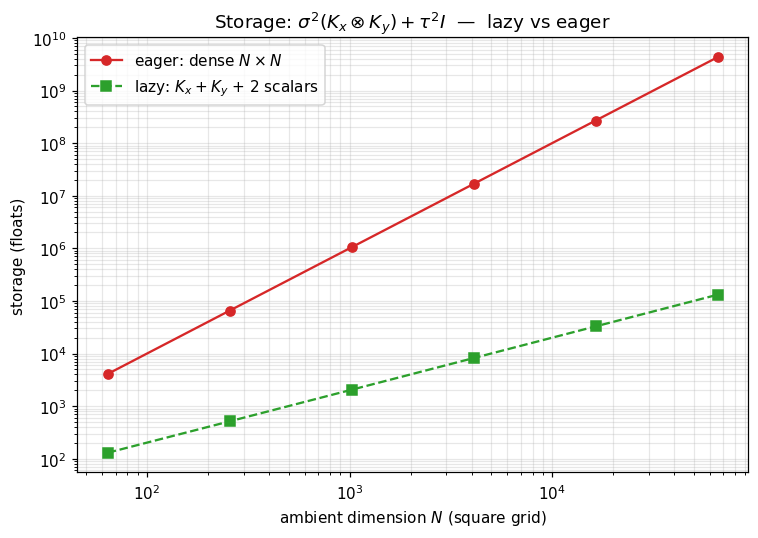

In [6]:
Ns = np.array([64, 256, 1024, 4096, 16384, 65536])
sqrtN = np.sqrt(Ns).astype(int)
lazy_floats  = 2 * sqrtN**2 + 2          # K_x + K_y + 2 scalars
eager_floats = Ns**2

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(Ns, eager_floats, "C3-",  marker="o", label="eager: dense $N\\times N$")
ax.loglog(Ns, lazy_floats,  "C2--", marker="s", label="lazy: $K_x + K_y$ + 2 scalars")
ax.set_xlabel("ambient dimension $N$ (square grid)")
ax.set_ylabel("storage (floats)")
ax.set_title(r"Storage: $\sigma^2 (K_x\otimes K_y) + \tau^2 I$  —  lazy vs eager")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 9. Common idioms cheatsheet

Six expressions every GP user writes, paired with the lazy form:

| Math | Lazy form | Notes |
|---|---|---|
| $\sigma^2 K + \tau^2 I$ | `Sum(Scaled(K, σ²), Scaled(I, τ²))` | tag both `Scaled` PSD if $\sigma^2, \tau^2 \geq 0$ |
| $K_{XX} + \mathrm{diag}(\sigma_i^2)$ | `Sum(K_XX, DiagonalLinearOperator(σ²_vec))` | heteroscedastic noise |
| $L K L^\top$ (whitening) | `Product(Product(L, K), L.T)` | tag with PSD if $K$ PSD |
| $K + UU^\top$ (rank-$k$ correction) | use `low_rank_plus_diag` directly | structured leaf, not lazy |
| $\sigma^2 K_x \otimes K_y + \tau^2 I$ | `Sum(Scaled(Kronecker(K_x, K_y), σ²), Scaled(I, τ²))` | the §5 demo |
| $K_{*X} K_{XX}^{-1}$ (cross-covariance) | precompute $K_{XX}^{-1}$, then `Product(K_starX, K_inv)` | usually the inv stays lazy via `solve` |

The last row is the most common GP-prediction pattern: never form $K_{XX}^{-1}$ explicitly — store it implicitly via a Cholesky factor and apply it through `solve` / `lx.linear_solve`. Lazy `Product` is for the *cross-covariance* layer that sits on top.

That is the algebra. The next four notebooks (1.3–1.6) introduce structured *leaves* (`KroneckerSum`, `Toeplitz`, `BlockTriDiag`, `MaskedOperator`) that the lazy combinators here will glue together; 1.7 then reveals how all of this dispatch is wired through the structural-tag system.